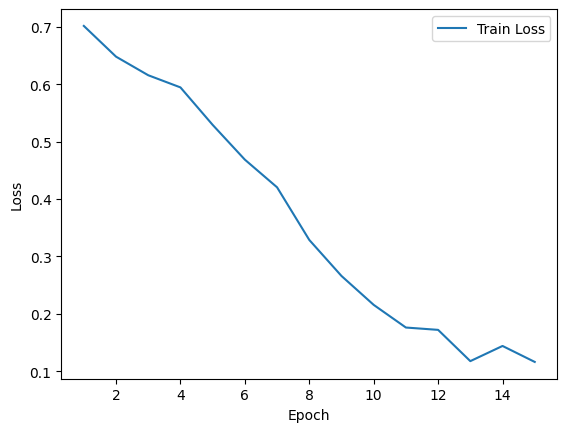

In [1]:
# to visualize training loss over epochs
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"F:\Experiments\Mtech Project DeepFaked Video and Audio analyzer\old models\ver2 with cache faces and MtCNN\training_log.csv")
plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


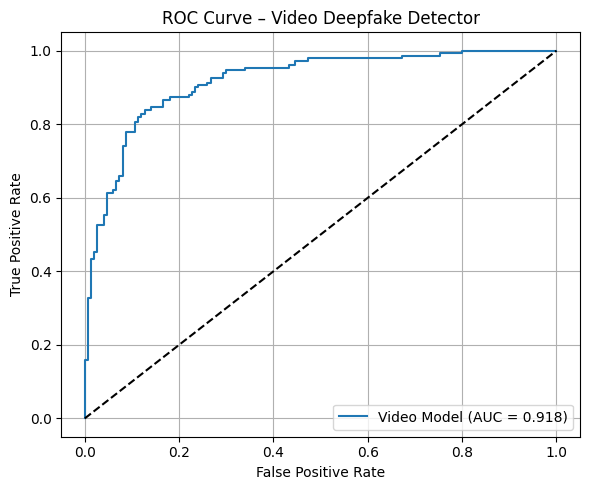

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

csv_path = r"F:\Experiments\Mtech Project DeepFaked Video and Audio analyzer\Models\video\test_predictions.csv"

df = pd.read_csv(csv_path)

y_true = df["true_label"]
y_score = df["pred_prob_fake"]

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Video Model (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Video Deepfake Detector")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [2]:
# Classification Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_true = df["true_label"]
y_pred = df["pred_class"]

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1-score :", f1_score(y_true, y_pred))


Accuracy : 0.8333333333333334
Precision: 0.7906976744186046
Recall   : 0.9066666666666666
F1-score : 0.84472049689441


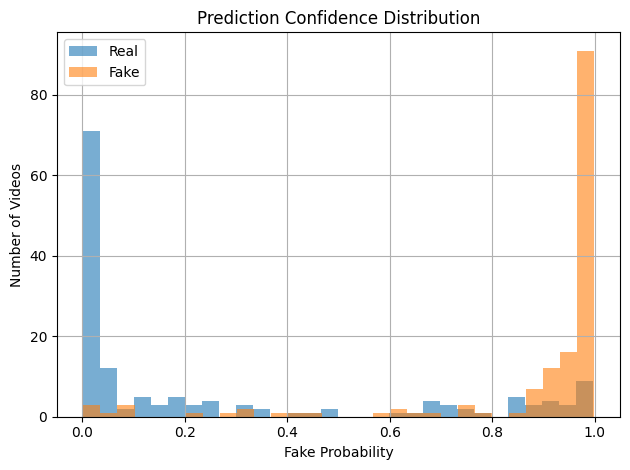

In [3]:
# Confidence Distribution
import matplotlib.pyplot as plt

real_scores = df[df.true_label == 0]["pred_prob_fake"]
fake_scores = df[df.true_label == 1]["pred_prob_fake"]

plt.hist(real_scores, bins=30, alpha=0.6, label="Real")
plt.hist(fake_scores, bins=30, alpha=0.6, label="Fake")

plt.xlabel("Fake Probability")
plt.ylabel("Number of Videos")
plt.title("Prediction Confidence Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
fp = df[(df.true_label == 0) & (df.pred_class == 1)]
fn = df[(df.true_label == 1) & (df.pred_class == 0)]

print("False Positives:", len(fp))
print("False Negatives:", len(fn))

fp.to_csv("false_positives.csv", index=False)
fn.to_csv("false_negatives.csv", index=False)


False Positives: 36
False Negatives: 14


In [7]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, f1_score

# Load predictions
df = pd.read_csv("test_predictions.csv")

y_true = df["true_label"].values
y_score = df["pred_prob_fake"].values

fpr, tpr, thresholds = roc_curve(y_true, y_score)

j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold_j = thresholds[best_idx]

print(f"Best Youden threshold: {best_threshold_j:.4f}")
print(f"TPR: {tpr[best_idx]:.3f}, FPR: {fpr[best_idx]:.3f}")


Best Youden threshold: 0.8735
TPR: 0.840, FPR: 0.127


In [8]:
thresholds = np.linspace(0, 1, 500)
f1_scores = []

for th in thresholds:
    preds = (y_score >= th).astype(int)
    f1_scores.append(f1_score(y_true, preds))

best_idx = np.argmax(f1_scores)
best_threshold_f1 = thresholds[best_idx]

print(f"Best F1 threshold: {best_threshold_f1:.4f}")
print(f"Best F1 score: {f1_scores[best_idx]:.3f}")


Best F1 threshold: 0.8617
Best F1 score: 0.854


In [9]:
target_fpr = 0.05

valid_idxs = np.where(fpr <= target_fpr)[0]
best_idx = valid_idxs[np.argmax(tpr[valid_idxs])]

best_threshold_fpr = thresholds[best_idx]

print(f"Threshold @ FPR≤5%: {best_threshold_fpr:.4f}")
print(f"TPR: {tpr[best_idx]:.3f}")


Threshold @ FPR≤5%: 0.0281
TPR: 0.613
